#  Think Like a Designer –  Data Visualizations

---

| | |
|---|---|
| **Course** | Data Visualization & UX Design |
| **Assignment** | Improving Data Visualizations |
| **Dataset** | sales_data.csv |
| **Tools** | Python · Pandas · Matplotlib · Seaborn · Plotly |

---

The dataset is a retail sales transaction records dataset — it simulates a store/e-commerce business's order history for the year 2023.

## 3. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print(" All libraries imported successfully.")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

 All libraries imported successfully.
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


## 4. Load CSV Dataset

In [5]:
df = pd.read_csv("sales_data.csv")
print(f" Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

 Dataset loaded: 500 rows × 9 columns


,Order_ID,Date,Region,Category,Sales,Quantity,Discount,Profit,Customer_Age
0,ORD-0001,2023-04-13,South,Clothing,278.17,16,0.35,-12.45,39
1,ORD-0002,2023-12-15,North,Electronics,1032.02,12,0.35,72.05,50
2,ORD-0003,2023-09-28,West,Clothing,84.78,8,0.35,84.73,47
3,ORD-0004,2023-04-17,East,Furniture,724.66,3,0.10,81.39,34
4,ORD-0005,2023-03-13,West,Sports,1479.44,16,0.18,-19.18,60


## 5. Data Overview

In [7]:
print(" First 5 rows")
df.head()

 First 5 rows


,Order_ID,Date,Region,Category,Sales,Quantity,Discount,Profit,Customer_Age
0,ORD-0001,2023-04-13,South,Clothing,278.17,16,0.35,-12.45,39
1,ORD-0002,2023-12-15,North,Electronics,1032.02,12,0.35,72.05,50
2,ORD-0003,2023-09-28,West,Clothing,84.78,8,0.35,84.73,47
3,ORD-0004,2023-04-17,East,Furniture,724.66,3,0.10,81.39,34
4,ORD-0005,2023-03-13,West,Sports,1479.44,16,0.18,-19.18,60


In [8]:
print("Data Types & Non-null Counts ")
df.info()

Data Types & Non-null Counts 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      500 non-null    object 
 1   Date          500 non-null    object 
 2   Region        500 non-null    object 
 3   Category      500 non-null    object 
 4   Sales         500 non-null    float64
 5   Quantity      500 non-null    int64  
 6   Discount      500 non-null    float64
 7   Profit        500 non-null    float64
 8   Customer_Age  500 non-null    int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 35.3+ KB


In [9]:
print(" Descriptive Statistics")
df.describe().round(2)

 Descriptive Statistics


,Sales,Quantity,Discount,Profit,Customer_Age
count,500.00,500.00,500.00,500.00,500.00
mean,344.22,9.99,0.20,77.09,43.71
std,278.27,5.54,0.12,59.54,14.77
min,50.31,1.00,0.00,-128.29,18.00
25%,137.83,5.00,0.11,36.00,31.00
50%,273.20,10.00,0.20,80.60,44.00
75%,459.56,15.00,0.30,120.31,57.00
max,1669.81,19.00,0.40,238.05,69.00


In [10]:
missing = df.isnull().sum()
print("Missing Values per Column")
print(missing[missing > 0] if missing.any() else " No missing values detected.")

Missing Values per Column
 No missing values detected.


## 6. Data Cleaning

In [11]:
# 1. Parse dates
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Month"]     = df["Date"].dt.to_period("M").astype(str)
    df["Month_Num"]  = df["Date"].dt.month
    df["Month_Name"] = df["Date"].dt.strftime("%b")
    print(" Date column parsed; Month, Month_Num, Month_Name columns added.")

#  2. Drop exact duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f" Duplicates removed: {before - len(df)} rows dropped ({len(df)} remain).")

# 3. Strip whitespace from string columns
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())
print(f" Whitespace stripped from {len(str_cols)} string columns.")

# 4. Cap negative Sales at 0
if "Sales" in df.columns:
    neg = (df["Sales"] < 0).sum()
    df["Sales"] = df["Sales"].clip(lower=0)
    print(f" Negative Sales capped to 0: {neg} rows affected.")

print("\n Cleaned dataset shape:", df.shape)

 Date column parsed; Month, Month_Num, Month_Name columns added.
 Duplicates removed: 0 rows dropped (500 remain).
 Whitespace stripped from 5 string columns.
 Negative Sales capped to 0: 0 rows affected.

 Cleaned dataset shape: (500, 12)


## 7. Visualization Improvements

For each chart type we present:
-  **Before** — a plain, default chart
-  **After** — a redesigned chart applying design principles

Design principles applied:
| Principle | Description |
|---|---|
| **Clarity** | Remove chart junk; maximize data-ink ratio |
| **Accuracy** | Honest axes, no truncated y-axis deception |
| **Colour** | Purposeful palette; accessible to colour-blind readers |
| **Labels** | Clear titles, axis labels, units, and annotations |
| **Hierarchy** | Guide the eye to the most important insight first |

### Visualization 1 — Bar Chart: Total Sales by Category

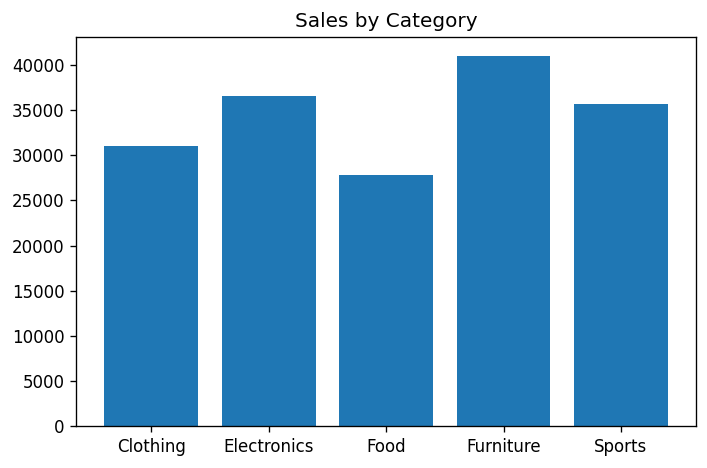

 BEFORE: Default bar chart — no ordering, no colour hierarchy, no units.


In [22]:
# Data preparation
cat_sales = df.groupby("Category")["Sales"].sum().reset_index()
cat_sales.columns = ["Category", "Total_Sales"]

# BEFORE — default, unstyled bar chart

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cat_sales["Category"], cat_sales["Total_Sales"])
ax.set_title("Sales by Category")
plt.tight_layout()
plt.savefig("bar_before.png", dpi=100, bbox_inches="tight")
plt.show()
print(" BEFORE: Default bar chart — no ordering, no colour hierarchy, no units.")

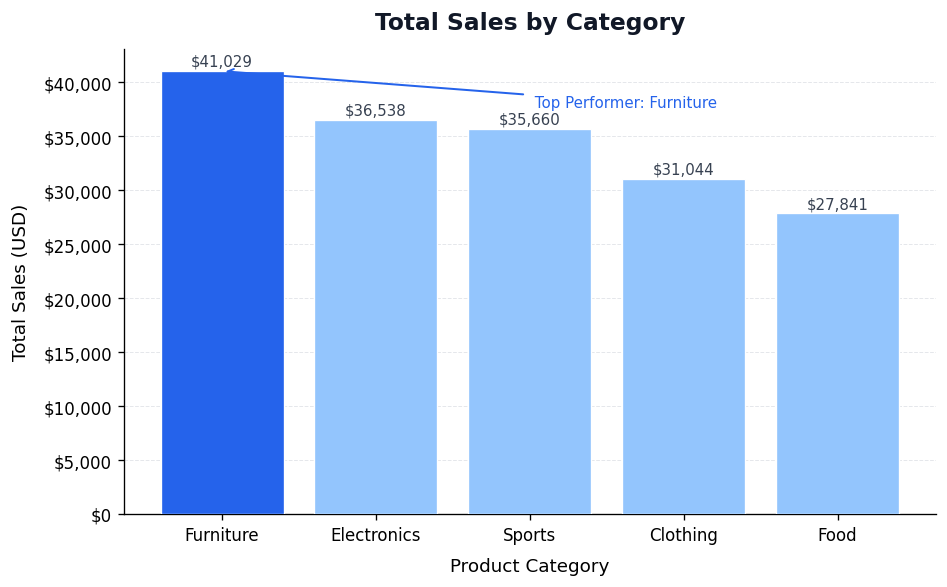

 AFTER: Sorted bars, highlight colour, value labels, clean grid, honest axes.


In [23]:

# AFTER — redesigned bar chart

cat_sales_sorted = cat_sales.sort_values("Total_Sales", ascending=False)
highlight = cat_sales_sorted["Category"].iloc[0]   # top category

palette = ["#2563EB" if c == highlight else "#93C5FD"
           for c in cat_sales_sorted["Category"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    cat_sales_sorted["Category"],
    cat_sales_sorted["Total_Sales"],
    color=palette, edgecolor="white", linewidth=0.8, zorder=3
)

# Grid behind bars
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, color="#E5E7EB", zorder=0)
ax.set_axisbelow(True)

# Value labels on each bar
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 200,
        f"${h:,.0f}", ha="center", va="bottom", fontsize=9, color="#374151"
    )

# Formatting
ax.set_title("Total Sales by Category", fontsize=14, fontweight="bold",
             pad=12, color="#111827")
ax.set_xlabel("Product Category", fontsize=11, labelpad=8)
ax.set_ylabel("Total Sales (USD)", fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

# Annotation for top performer
ax.annotate(
    f" Top Performer: {highlight}",
    xy=(0, cat_sales_sorted["Total_Sales"].iloc[0]),
    xytext=(2, cat_sales_sorted["Total_Sales"].max() * 0.92),
    fontsize=9, color="#2563EB",
    arrowprops=dict(arrowstyle="->", color="#2563EB", lw=1.2)
)

plt.tight_layout()
plt.savefig("bar_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(" AFTER: Sorted bars, highlight colour, value labels, clean grid, honest axes.")

### Visualization 2 — Line Chart: Monthly Sales Trend

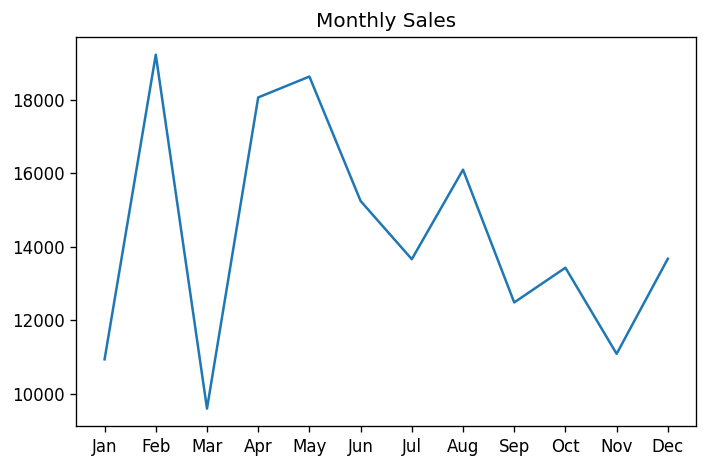

 BEFORE: Plain line, no markers, no units, no context.


In [24]:
# ── Data preparation ─────────────────────────────────────────────────────────
monthly = (
    df.groupby("Month_Num")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Month_Num")
)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["Month_Label"] = monthly["Month_Num"].apply(
    lambda x: month_labels[x - 1] if 1 <= x <= 12 else str(x)
)

#  BEFORE
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(monthly["Month_Label"], monthly["Sales"])
ax.set_title("Monthly Sales")
plt.tight_layout()
plt.show()
print(" BEFORE: Plain line, no markers, no units, no context.")

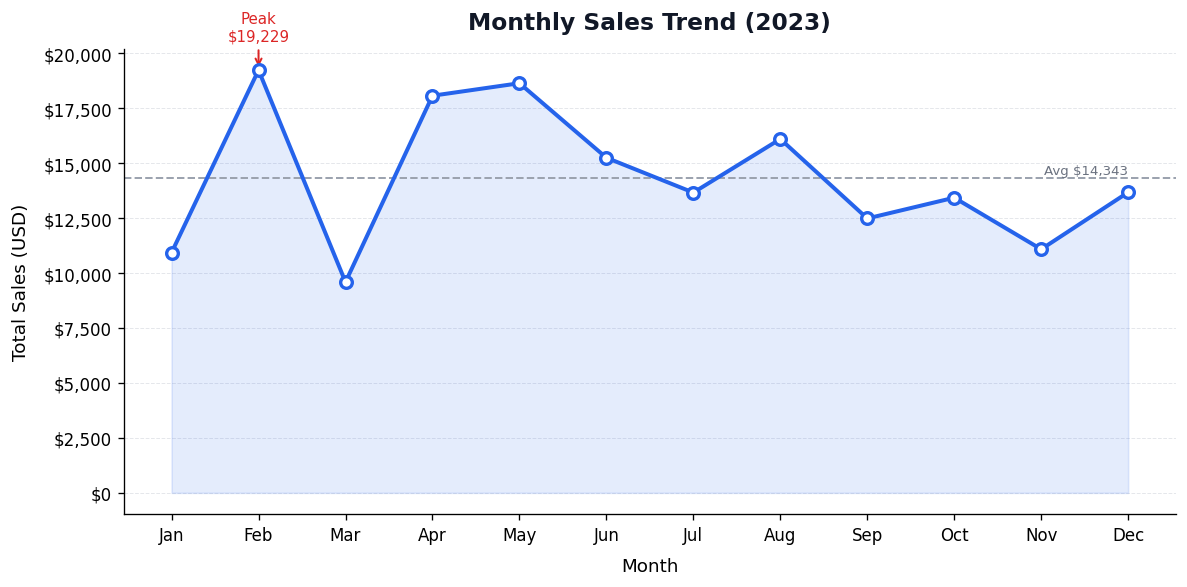

 AFTER: Filled area, data markers, peak annotation, average reference line.


In [25]:
#  AFTER
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded area under the line
ax.fill_between(monthly["Month_Label"], monthly["Sales"],
                alpha=0.12, color="#2563EB")

# Main line with markers
ax.plot(monthly["Month_Label"], monthly["Sales"],
        color="#2563EB", linewidth=2.4, marker="o",
        markersize=7, markerfacecolor="white",
        markeredgecolor="#2563EB", markeredgewidth=2, zorder=5)

# Highlight peak month
peak_idx = monthly["Sales"].idxmax()
peak_month = monthly.loc[peak_idx, "Month_Label"]
peak_val   = monthly.loc[peak_idx, "Sales"]
ax.annotate(
    f"Peak\n${peak_val:,.0f}",
    xy=(peak_month, peak_val),
    xytext=(peak_month, peak_val * 1.07),
    ha="center", fontsize=9, color="#DC2626",
    arrowprops=dict(arrowstyle="->", color="#DC2626", lw=1.2)
)

# Average reference line
avg = monthly["Sales"].mean()
ax.axhline(avg, color="#9CA3AF", linestyle="--", linewidth=1.2)
ax.text(monthly["Month_Label"].iloc[-1], avg * 1.01,
        f"Avg ${avg:,.0f}", fontsize=8, color="#6B7280", ha="right")

# Formatting
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, color="#E5E7EB", zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Monthly Sales Trend (2023)", fontsize=14,
             fontweight="bold", pad=12, color="#111827")
ax.set_xlabel("Month", fontsize=11, labelpad=8)
ax.set_ylabel("Total Sales (USD)", fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig("line_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(" AFTER: Filled area, data markers, peak annotation, average reference line.")

### Visualization 3 — Scatter Plot: Sales vs. Profit

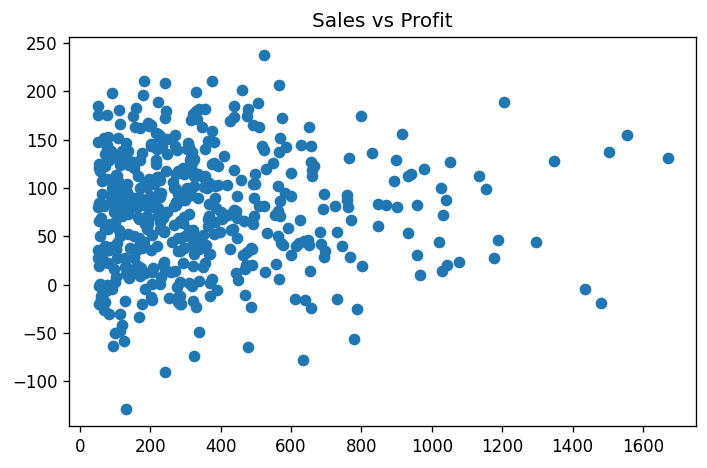

 BEFORE: Undifferentiated dots, no colour encoding, no trend line, overplotting.


In [26]:
#  BEFORE
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["Sales"], df["Profit"])
ax.set_title("Sales vs Profit")
plt.tight_layout()
plt.show()
print(" BEFORE: Undifferentiated dots, no colour encoding, no trend line, overplotting.")

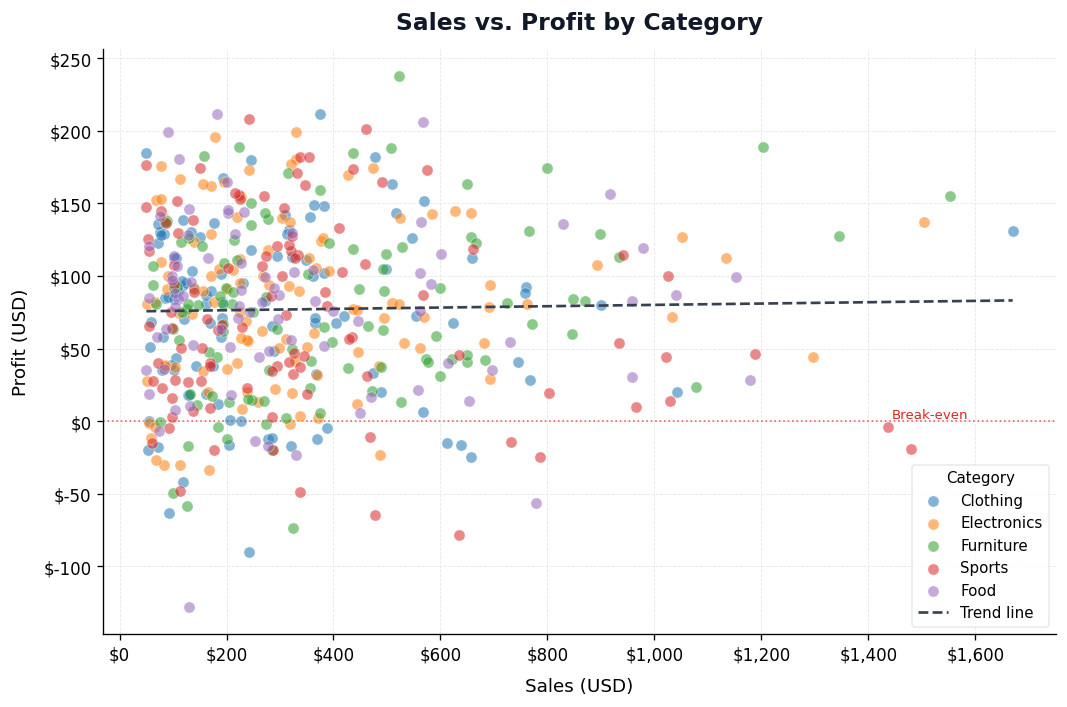

 AFTER: Category colour encoding, trend line, break-even reference, legend.


In [27]:
#  AFTER
fig, ax = plt.subplots(figsize=(9, 6))

categories = df["Category"].unique()
palette_cats = sns.color_palette("tab10", n_colors=len(categories))
colour_map = dict(zip(categories, palette_cats))

for cat in categories:
    subset = df[df["Category"] == cat]
    ax.scatter(
        subset["Sales"], subset["Profit"],
        label=cat, alpha=0.55, s=45,
        color=colour_map[cat], edgecolors="white", linewidths=0.4, zorder=3
    )

# Regression / trend line
z = np.polyfit(df["Sales"].dropna(), df["Profit"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df["Sales"].min(), df["Sales"].max(), 200)
ax.plot(x_line, p(x_line), "--", color="#374151", linewidth=1.6,
        label="Trend line", zorder=4)

# Zero profit reference line
ax.axhline(0, color="#DC2626", linewidth=1, linestyle=":", alpha=0.7)
ax.text(df["Sales"].max() * 0.95, 2, "Break-even",
        ha="right", fontsize=8, color="#DC2626")

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#E5E7EB", zorder=0)
ax.xaxis.grid(True, linestyle="--", linewidth=0.5, color="#E5E7EB", zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Sales vs. Profit by Category", fontsize=14,
             fontweight="bold", pad=12, color="#111827")
ax.set_xlabel("Sales (USD)", fontsize=11, labelpad=8)
ax.set_ylabel("Profit (USD)", fontsize=11, labelpad=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Category", fontsize=9, title_fontsize=9,
          framealpha=0.85, edgecolor="#E5E7EB")
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig("scatter_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(" AFTER: Category colour encoding, trend line, break-even reference, legend.")

### Visualization 4 — Histogram: Distribution of Sales

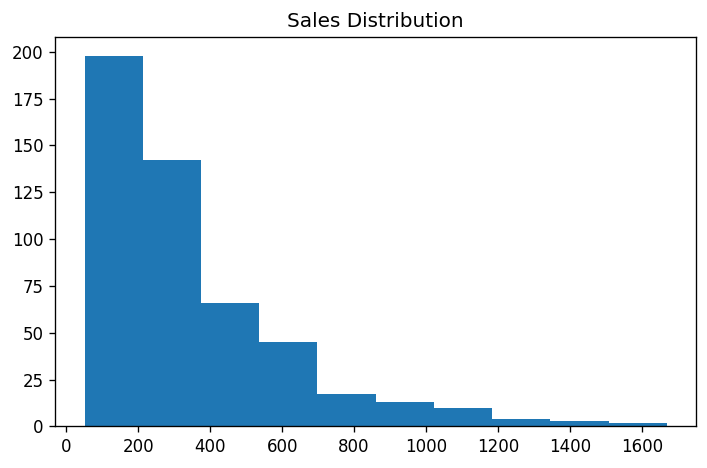

 BEFORE: Arbitrary bin count, no KDE, no mean/median markers.


In [28]:
#  BEFORE
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["Sales"])
ax.set_title("Sales Distribution")
plt.tight_layout()
plt.show()
print(" BEFORE: Arbitrary bin count, no KDE, no mean/median markers.")

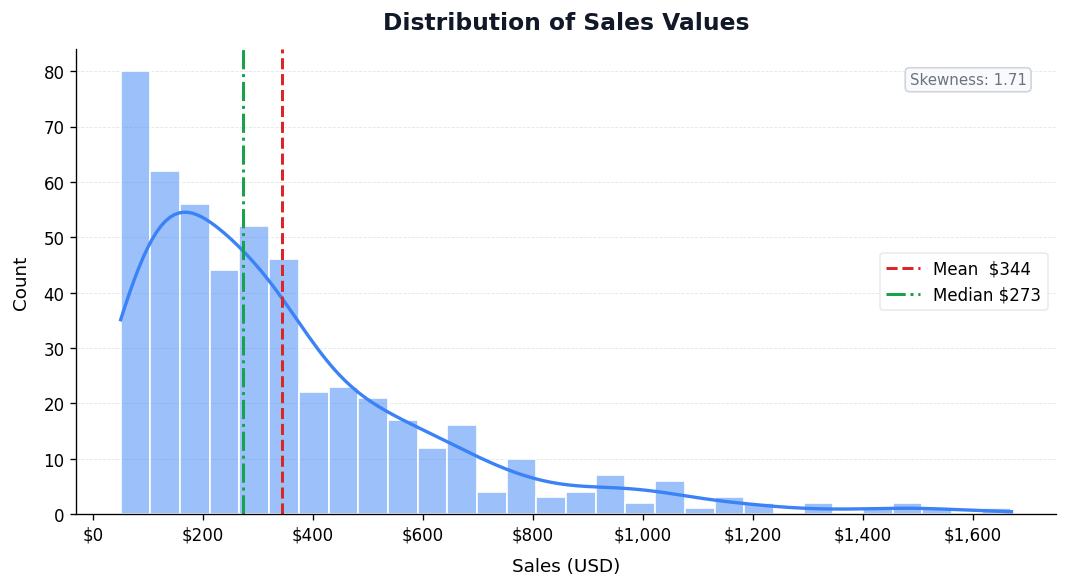

 AFTER: KDE overlay, mean/median markers, 30 bins, skewness annotation.


In [29]:
#  AFTER
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    df["Sales"], bins=30, kde=True, ax=ax,
    color="#3B82F6", edgecolor="white",
    line_kws={"linewidth": 2, "color": "#1D4ED8"}
)

# Mean and Median lines
mean_val   = df["Sales"].mean()
median_val = df["Sales"].median()

ax.axvline(mean_val, color="#DC2626", linestyle="--", linewidth=1.8, label=f"Mean  ${mean_val:,.0f}")
ax.axvline(median_val, color="#16A34A", linestyle="-.", linewidth=1.8, label=f"Median ${median_val:,.0f}")

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#E5E7EB", zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Distribution of Sales Values", fontsize=14,
             fontweight="bold", pad=12, color="#111827")
ax.set_xlabel("Sales (USD)", fontsize=11, labelpad=8)
ax.set_ylabel("Count", fontsize=11, labelpad=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=10, framealpha=0.85, edgecolor="#E5E7EB")
ax.tick_params(axis="both", labelsize=10)

# Skewness annotation
skew = df["Sales"].skew()
ax.text(0.97, 0.95, f"Skewness: {skew:.2f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color="#6B7280",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#F9FAFB", edgecolor="#D1D5DB"))

plt.tight_layout()
plt.savefig("hist_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(" AFTER: KDE overlay, mean/median markers, 30 bins, skewness annotation.")

### Visualization 5 — Interactive Plotly: Sales & Profit by Region and Category

In [30]:
#  BEFORE — basic Plotly bar with no customisation
fig_before = px.bar(
    df.groupby("Region")["Sales"].sum().reset_index(),
    x="Region", y="Sales",
    title="Sales by Region"
)
fig_before.show()
print(" BEFORE: Default Plotly colours, no hover detail, no interactivity beyond tooltip.")

 BEFORE: Default Plotly colours, no hover detail, no interactivity beyond tooltip.


In [31]:
#  AFTER — rich interactive grouped bar with custom hover
region_cat = (
    df.groupby(["Region", "Category"])
    .agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"),
         Order_Count=("Sales", "count"))
    .reset_index()
)
region_cat["Profit_Margin"] = (
    region_cat["Total_Profit"] / region_cat["Total_Sales"] * 100
).round(1)

fig_after = px.bar(
    region_cat,
    x="Region",
    y="Total_Sales",
    color="Category",
    barmode="group",
    text="Total_Sales",
    custom_data=["Total_Profit", "Profit_Margin", "Order_Count"],
    title="💰 Sales & Profit by Region and Category",
    labels={"Total_Sales": "Total Sales (USD)", "Region": "Sales Region"},
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_after.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    hovertemplate=(
        "<b>%{x} — %{data.name}</b><br>"
        "Sales: $%{y:,.0f}<br>"
        "Profit: $%{customdata[0]:,.0f}<br>"
        "Margin: %{customdata[1]:.1f}%<br>"
        "Orders: %{customdata[2]}<extra></extra>"
    )
)

fig_after.update_layout(
    font_family="Inter, Arial, sans-serif",
    title_font_size=18,
    title_x=0.03,
    plot_bgcolor="#FAFAFA",
    paper_bgcolor="white",
    xaxis=dict(title_font_size=13, showgrid=False),
    yaxis=dict(
        title_font_size=13,
        gridcolor="#E5E7EB",
        tickformat="$,.0f"
    ),
    legend=dict(
        title="Category",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="#E5E7EB",
        borderwidth=1
    ),
    bargap=0.18,
    bargroupgap=0.06,
    margin=dict(t=80, b=60)
)

fig_after.show()
print(" AFTER: Grouped bars, rich hover (profit, margin, order count), custom palette, clean layout.")

 AFTER: Grouped bars, rich hover (profit, margin, order count), custom palette, clean layout.


### Visualization 6 — Box Plot: Sales Distribution by Category

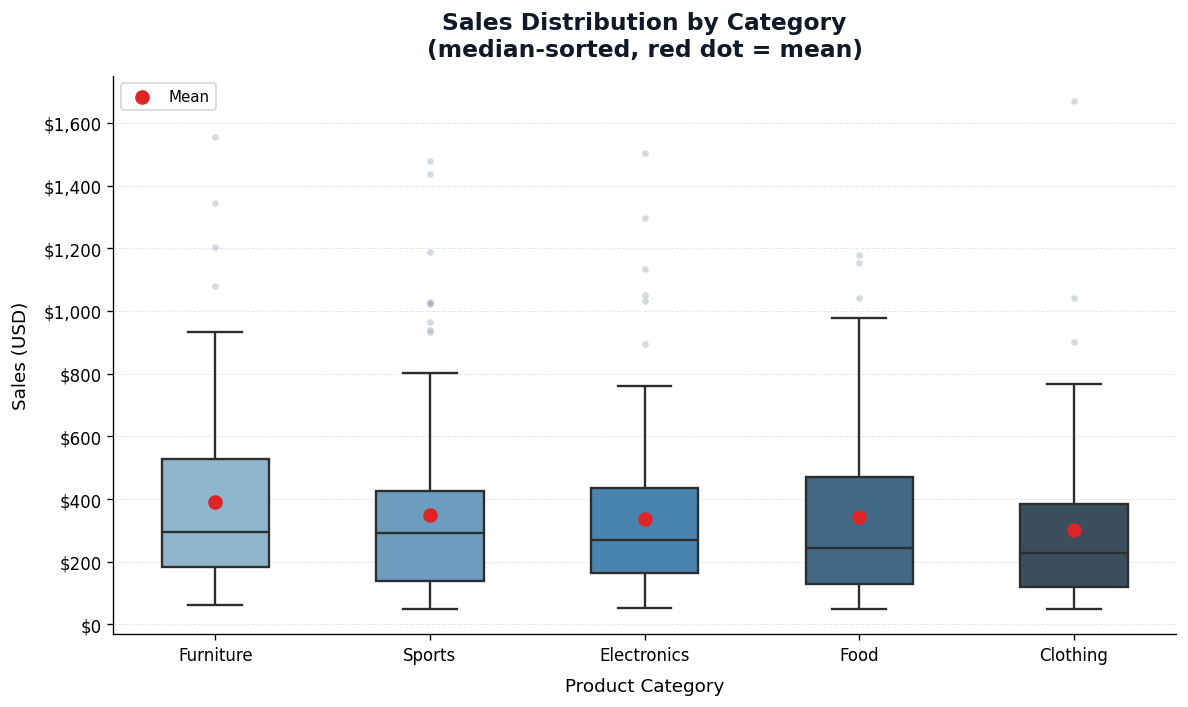

 Box Plot: Shows spread, median, outliers & mean per category.


In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

order = df.groupby('Category')['Sales'].median().sort_values(ascending=False).index
palette = sns.color_palette('Blues_d', n_colors=len(order))

sns.boxplot(
    data=df, x='Category', y='Sales',
    order=order, palette=palette,
    width=0.5, linewidth=1.4,
    flierprops=dict(marker='o', markersize=4, alpha=0.4,
                    markerfacecolor='#94A3B8', markeredgewidth=0),
    ax=ax
)

# Overlay mean dots
means = df.groupby('Category')['Sales'].mean()
for i, cat in enumerate(order):
    ax.scatter(i, means[cat], color='#DC2626', zorder=5, s=60,
               label='Mean' if i == 0 else '')

ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#E5E7EB', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
ax.set_title('Sales Distribution by Category\n(median-sorted, red dot = mean)',
             fontsize=14, fontweight='bold', pad=12, color='#111827')
ax.set_xlabel('Product Category', fontsize=11, labelpad=8)
ax.set_ylabel('Sales (USD)', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(fontsize=9)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Box Plot: Shows spread, median, outliers & mean per category.')

### Visualization 7 — Stacked Bar Chart: Sales Mix by Region

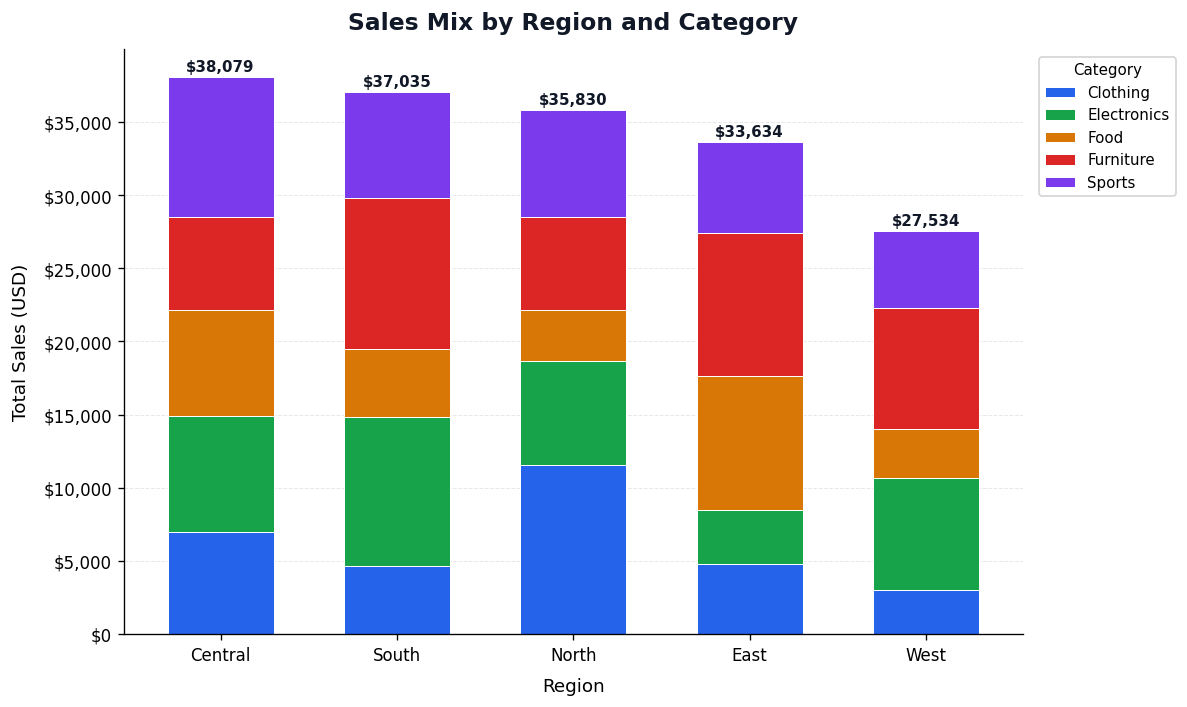

 Stacked Bar: Part-to-whole composition of sales across regions.


In [33]:
pivot = df.pivot_table(index='Region', columns='Category',
                       values='Sales', aggfunc='sum').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

colors = ['#2563EB','#16A34A','#D97706','#DC2626','#7C3AED']
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors,
           edgecolor='white', linewidth=0.6, width=0.6)

# Total labels on top of each bar
for i, (idx, row) in enumerate(pivot.iterrows()):
    total = row.sum()
    ax.text(i, total + 200, f'${total:,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#111827')

ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#E5E7EB', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
ax.set_title('Sales Mix by Region and Category',
             fontsize=14, fontweight='bold', pad=12, color='#111827')
ax.set_xlabel('Region', fontsize=11, labelpad=8)
ax.set_ylabel('Total Sales (USD)', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(title='Category', bbox_to_anchor=(1.01,1), loc='upper left',
          fontsize=9, title_fontsize=9, framealpha=0.85)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Stacked Bar: Part-to-whole composition of sales across regions.')

### Visualization 8 — Violin Plot: Profit Distribution by Region

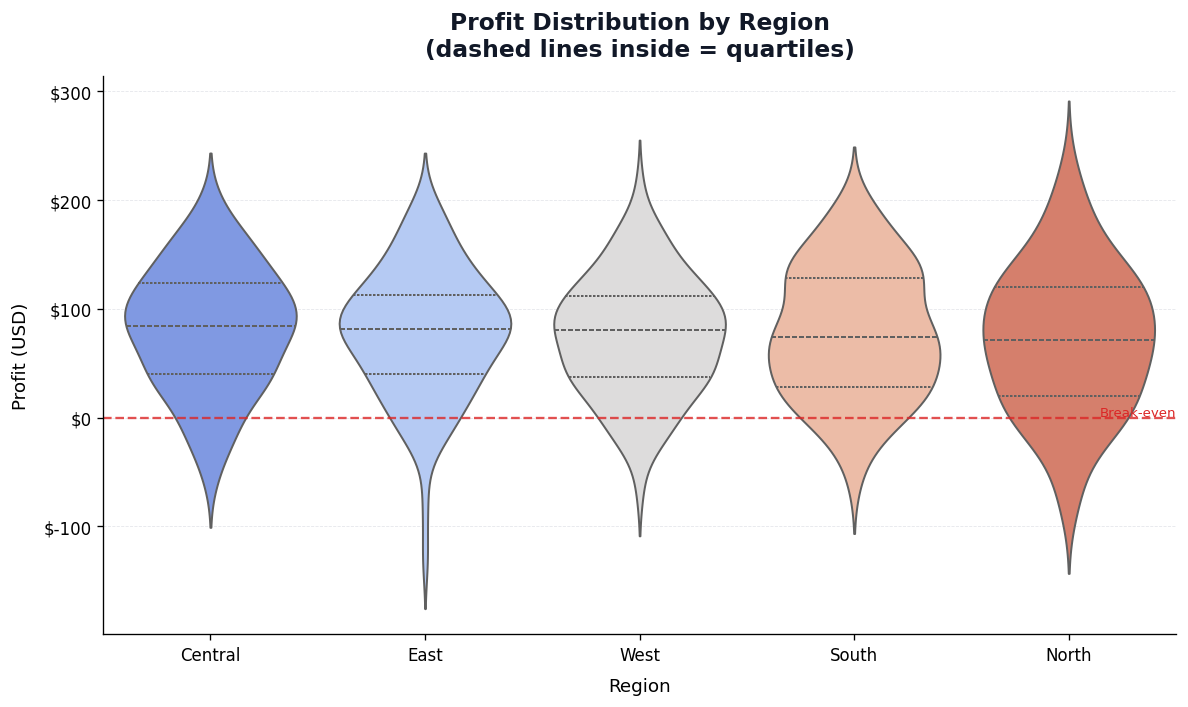

🎻 Violin Plot: Full profit distribution shape + quartiles per region.


In [34]:
order_r = df.groupby('Region')['Profit'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=df, x='Region', y='Profit',
    order=order_r,
    palette='coolwarm',
    inner='quartile',
    linewidth=1.2,
    ax=ax
)

ax.axhline(0, color='#DC2626', linewidth=1.4, linestyle='--', alpha=0.8)
ax.text(len(order_r)-0.5, 2, 'Break-even',
        ha='right', fontsize=8, color='#DC2626')

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#E5E7EB', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
ax.set_title('Profit Distribution by Region\n(dashed lines inside = quartiles)',
             fontsize=14, fontweight='bold', pad=12, color='#111827')
ax.set_xlabel('Region', fontsize=11, labelpad=8)
ax.set_ylabel('Profit (USD)', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('🎻 Violin Plot: Full profit distribution shape + quartiles per region.')

### Visualization 9 — Interactive Donut Chart: Revenue Share by Category

In [35]:
cat_rev = df.groupby('Category')['Sales'].sum().reset_index()
cat_rev.columns = ['Category', 'Total_Sales']

fig_donut = go.Figure(go.Pie(
    labels=cat_rev['Category'],
    values=cat_rev['Total_Sales'],
    hole=0.48,
    textinfo='label+percent',
    hovertemplate='<b>%{label}</b><br>Revenue: $%{value:,.0f}<br>Share: %{percent}<extra></extra>',
    marker=dict(
        colors=px.colors.qualitative.Bold,
        line=dict(color='white', width=2)
    ),
    textfont_size=12
))

total_rev = cat_rev['Total_Sales'].sum()
fig_donut.add_annotation(
    text=f'<b>Total</b><br>${total_rev:,.0f}',
    x=0.5, y=0.5, showarrow=False,
    font=dict(size=14, color='#111827')
)

fig_donut.update_layout(
    title=dict(text=' Revenue Share by Product Category', x=0.03, font_size=17),
    font_family='Inter, Arial, sans-serif',
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(orientation='v', x=1.02, y=0.5,
                bgcolor='rgba(255,255,255,0.85)',
                bordercolor='#E5E7EB', borderwidth=1),
    margin=dict(t=80, b=40, l=40, r=40)
)

fig_donut.show()
print(' Donut Chart: Proportional revenue share — hover for exact values.')

 Donut Chart: Proportional revenue share — hover for exact values.


### Visualization 10 — Interactive Bubble Chart: Region Performance Overview

In [36]:
bubble_df = df.groupby('Region').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Order_Count=('Sales','count'),
    Avg_Discount=('Discount','mean')
).reset_index()
bubble_df['Profit_Margin'] = (bubble_df['Total_Profit'] / bubble_df['Total_Sales'] * 100).round(1)

fig_bubble = px.scatter(
    bubble_df,
    x='Total_Sales', y='Total_Profit',
    size='Order_Count',
    color='Region',
    text='Region',
    custom_data=['Order_Count','Profit_Margin','Avg_Discount'],
    title=' Region Performance: Sales vs Profit (bubble = order volume)',
    labels={'Total_Sales':'Total Sales (USD)','Total_Profit':'Total Profit (USD)'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    size_max=70
)

fig_bubble.update_traces(
    textposition='top center',
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Sales: $%{x:,.0f}<br>'
        'Profit: $%{y:,.0f}<br>'
        'Orders: %{customdata[0]}<br>'
        'Margin: %{customdata[1]:.1f}%<br>'
        'Avg Discount: %{customdata[2]:.0%}<extra></extra>'
    )
)

fig_bubble.update_layout(
    font_family='Inter, Arial, sans-serif',
    title_font_size=17, title_x=0.03,
    plot_bgcolor='#FAFAFA', paper_bgcolor='white',
    xaxis=dict(tickformat='$,.0f', gridcolor='#E5E7EB', title_font_size=12),
    yaxis=dict(tickformat='$,.0f', gridcolor='#E5E7EB', title_font_size=12),
    margin=dict(t=80, b=60)
)

fig_bubble.show()
print(' Bubble Chart: 3 dimensions — sales, profit, and order volume per region.')

 Bubble Chart: 3 dimensions — sales, profit, and order volume per region.


### Visualization 11 — Interactive Multi-Line Chart: Monthly Sales Trend by Category

In [37]:
monthly_cat = (
    df.groupby(['Month_Num','Category'])['Sales']
    .sum().reset_index()
    .sort_values('Month_Num')
)
m_labels = ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_cat['Month_Label'] = monthly_cat['Month_Num'].apply(
    lambda x: m_labels[x-1] if 1 <= x <= 12 else str(x)
)

fig_ml = px.line(
    monthly_cat, x='Month_Label', y='Sales',
    color='Category',
    markers=True,
    title=' Monthly Sales Trend by Category (2023)',
    labels={'Sales':'Total Sales (USD)','Month_Label':'Month'},
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_ml.update_traces(
    line=dict(width=2.5),
    marker=dict(size=8),
    hovertemplate='<b>%{fullData.name}</b><br>Month: %{x}<br>Sales: $%{y:,.0f}<extra></extra>'
)

fig_ml.update_layout(
    font_family='Inter, Arial, sans-serif',
    title_font_size=17, title_x=0.03,
    plot_bgcolor='#FAFAFA', paper_bgcolor='white',
    xaxis=dict(showgrid=False, title_font_size=12),
    yaxis=dict(tickformat='$,.0f', gridcolor='#E5E7EB', title_font_size=12),
    legend=dict(title='Category', bgcolor='rgba(255,255,255,0.85)',
                bordercolor='#E5E7EB', borderwidth=1),
    hovermode='x unified',
    margin=dict(t=80, b=60)
)

fig_ml.show()
print(' Multi-Line: Compare seasonal trends across all 5 categories simultaneously.')

 Multi-Line: Compare seasonal trends across all 5 categories simultaneously.


## 10. Final Design Evaluation

| # | Chart Type | Insight Delivered | Key Design Choice |
|---|---|---|---|
| 1 | Bar Chart | Top revenue category | Sorted + highlighted bar |
| 2 | Line Chart | Sales seasonality | Filled area + peak annotation |
| 3 | Scatter Plot | Sales–profit relationship | Category colour + trend line |
| 4 | Histogram | Sales value distribution | KDE + mean/median markers |
| 5 | Plotly Grouped Bar | Region × Category performance | Rich hover with margin & orders |
| 6 | Box Plot | Spread & outliers per category | Median-sorted + mean dot overlay |
| 7 | Stacked Bar | Revenue composition by region | Part-to-whole with total labels |
| 8 | Violin Plot | Profit shape per region | Inner quartile lines + break-even line |
| 9 | Donut Chart | Revenue share proportions | Centre total annotation |
| 10 | Bubble Chart | Region: sales, profit & volume | 3 variables in one view |
| 11 | Multi-Line Chart | Category trends over 12 months | Unified hover for easy comparison |

---

> *Good visualization design answers a specific question. Every chart above was built around one clear business question — making each insight immediately accessible to any reader.*